<a href="https://colab.research.google.com/github/liaalcantara01/CDA-UTEC/blob/main/Copia_de_Lab4_2_seaborn_subplots_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización con Seaborn y Paneles Múltiples
## Ciencia de Datos Ambientales – Aplicado al Perú

**Objetivos de aprendizaje:**
- Crear histogramas y diagramas de caja para distribuciones
- Construir figuras de múltiples paneles con subgráficos
- Usar Seaborn para visualizaciones estadísticas más limpias
- Guardar figuras con calidad de publicación

**Entorno:** Google Colab

---

In [1]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# Crear conjuntos de datos ambientales peruanos
np.random.seed(42)

# Dataset 1: Monitoreo diario del río Ucayali (estación Pucallpa – SENAMHI)
fechas       = pd.date_range('2024-01-01', '2024-12-31', freq='D')
n_dias       = len(fechas)
dia_del_anio = np.arange(n_dias)
temp_estacional = 28 + 3 * np.sin(2 * np.pi * (dia_del_anio - 30) / 365)
caudal_base     = 2000 + 1500 * np.sin(2 * np.pi * (dia_del_anio - 45) / 365)

datos_rio = pd.DataFrame({
    'fecha'        : fechas,
    'temperatura_c': temp_estacional + np.random.normal(0, 1.5, n_dias),
    'caudal_m3s'   : np.maximum(caudal_base + np.random.normal(0, 300, n_dias), 50),
    'mes'          : fechas.month,
    'estacion'     : pd.cut(fechas.month, bins=[0, 3, 6, 9, 12],
                            labels=['Verano', 'Otoño', 'Invierno', 'Primavera'])
})

# Dataset 2: Inventario forestal – Madre de Dios (SERFOR)
np.random.seed(123)
n_arboles = 120

datos_arboles = pd.DataFrame({
    'especie': np.random.choice(
        ['Swietenia macrophylla', 'Cedrela odorata',
         'Cedrelinga cateniformis', 'Virola surinamensis'],
        n_arboles, p=[0.30, 0.35, 0.25, 0.10]),
    'dap_cm': np.random.uniform(15, 70, n_arboles),
    'parcela': np.random.choice(['MDD_023', 'MDD_024', 'MDD_025'], n_arboles)
})
datos_arboles['altura_m'] = (
    6 + 0.42 * datos_arboles['dap_cm']
    + np.random.normal(0, 3.5, n_arboles)
).clip(lower=4)

# Dataset 3: Calidad del agua – Cuenca del Mantaro (INAIGEM)
n_muestras = 40
calidad_agua = pd.DataFrame({
    'sitio': np.repeat(['Junín (cabecera)', 'Huancayo (medio)', 'Pampas (bajo)'], n_muestras),
    'ph': np.concatenate([
        np.random.normal(7.5, 0.3, n_muestras),
        np.random.normal(7.0, 0.4, n_muestras),
        np.random.normal(6.2, 0.5, n_muestras)
    ]),
    'oxigeno_disuelto': np.concatenate([
        np.random.normal(7.8, 0.8, n_muestras),
        np.random.normal(6.5, 1.0, n_muestras),
        np.random.normal(4.2, 1.2, n_muestras)
    ])
})

print("¡Conjuntos de datos listos!")

¡Conjuntos de datos listos!


---
## 1. Histogramas

**Ideales para:** Mostrar la distribución de una variable continua

### 1.1 Histograma básico

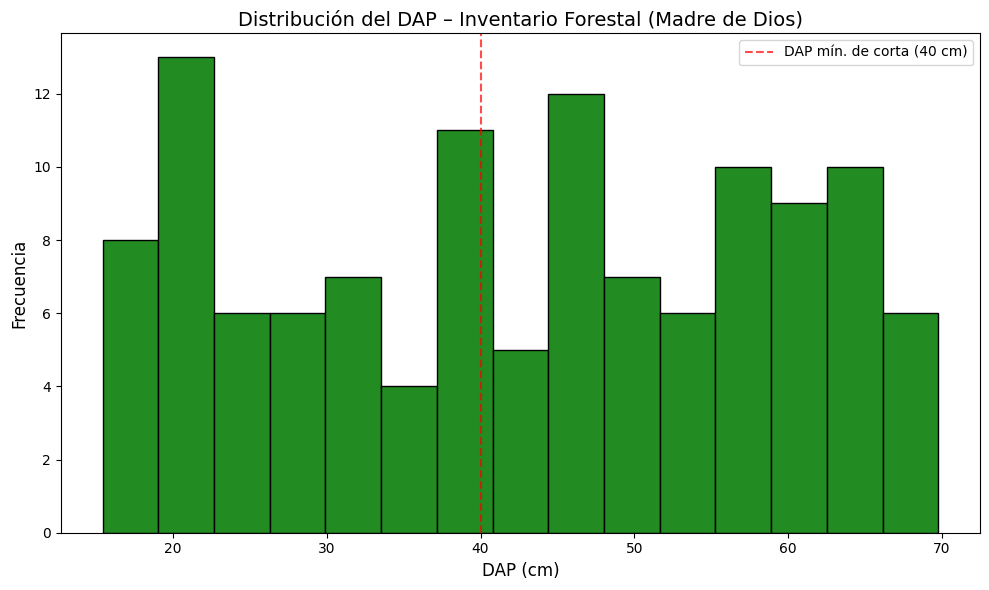

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(datos_arboles['dap_cm'], bins=15, color='forestgreen', edgecolor='black')

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del DAP – Inventario Forestal (Madre de Dios)', fontsize=14)
ax.axvline(40, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label='DAP mín. de corta (40 cm)')
ax.legend()

plt.tight_layout()
plt.show()

### 1.2 Añadir estadísticas de resumen

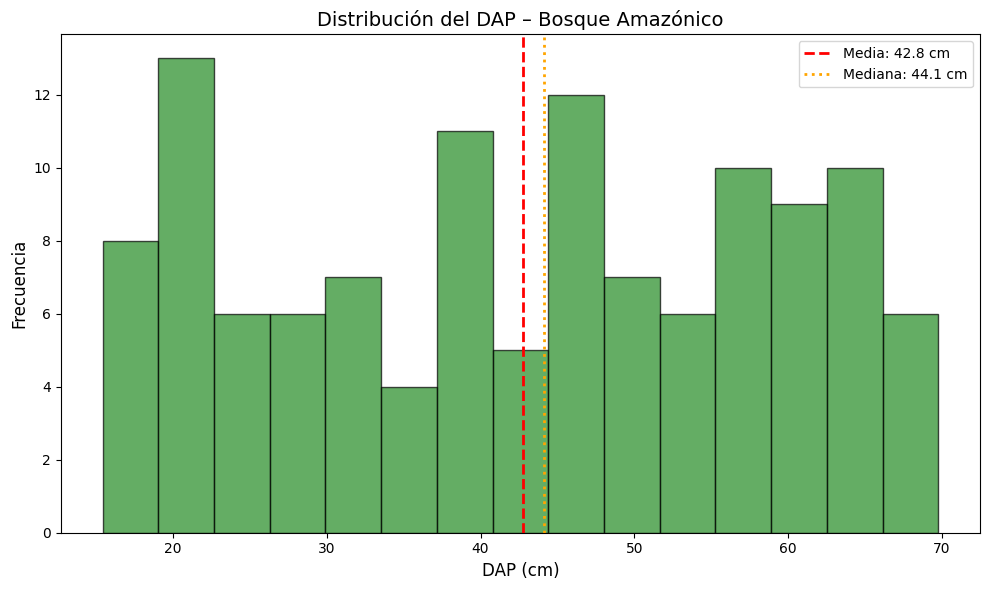

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(datos_arboles['dap_cm'], bins=15, color='forestgreen',
        edgecolor='black', alpha=0.7)

# Líneas verticales de media y mediana
media_dap  = datos_arboles['dap_cm'].mean()
mediana_dap = datos_arboles['dap_cm'].median()

ax.axvline(media_dap,   color='red',    linestyle='--', linewidth=2,
           label=f'Media: {media_dap:.1f} cm')
ax.axvline(mediana_dap, color='orange', linestyle=':', linewidth=2,
           label=f'Mediana: {mediana_dap:.1f} cm')

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del DAP – Bosque Amazónico', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

### 1.3 Comparar distribuciones

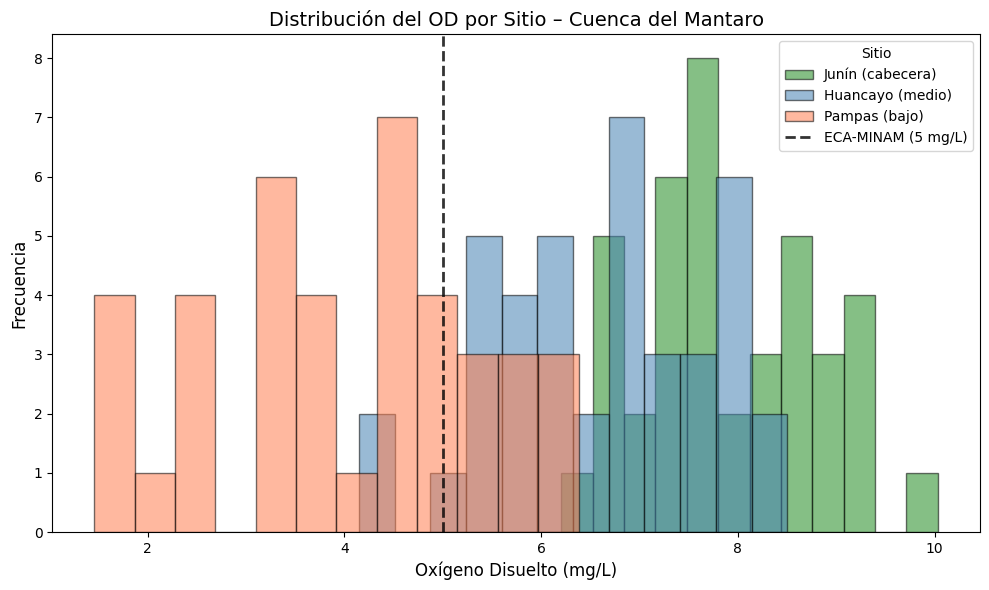

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Histogramas superpuestos por sitio
for sitio, color in zip(['Junín (cabecera)', 'Huancayo (medio)', 'Pampas (bajo)'],
                         ['forestgreen', 'steelblue', 'coral']):
    datos = calidad_agua[calidad_agua['sitio'] == sitio]['oxigeno_disuelto']
    ax.hist(datos, bins=12, alpha=0.55, label=sitio, color=color, edgecolor='black')

# Línea ECA-MINAM (OD mínimo = 5 mg/L para categoría 3)
ax.axvline(5, color='black', linestyle='--', linewidth=2, alpha=0.8,
           label='ECA-MINAM (5 mg/L)')

ax.set_xlabel('Oxígeno Disuelto (mg/L)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del OD por Sitio – Cuenca del Mantaro', fontsize=14)
ax.legend(title='Sitio')

plt.tight_layout()
plt.show()

---
## 2. Diagramas de Caja (Box Plots)

**Ideales para:** Comparar distribuciones entre grupos, identificar valores atípicos

### 2.1 Anatomía de un diagrama de caja

In [ ]:
print("""
Anatomía del Diagrama de Caja:
═══════════════════════════════════════════════════

         ┬ ─── Máximo (dentro de 1.5×RIC desde Q3)
         │
         │
    ┌────┴────┐
    │         │ ─── Q3 (percentil 75)
    │─────────│ ─── Mediana (Q2, percentil 50)
    │         │ ─── Q1 (percentil 25)
    └────┬────┘
         │       RIC = Q3 − Q1 (Rango Intercuartílico)
         ┴ ─── Mínimo (dentro de 1.5×RIC desde Q1)

    ○    ○ ─── Valores atípicos (fuera de 1.5×RIC)

═══════════════════════════════════════════════════
"""
)


Anatomía del Diagrama de Caja:
═══════════════════════════════════════════════════

         ┬ ─── Máximo (dentro de 1.5×RIC desde Q3)
         │
         │
    ┌────┴────┐
    │         │ ─── Q3 (percentil 75)
    │─────────│ ─── Mediana (Q2, percentil 50)
    │         │ ─── Q1 (percentil 25)
    └────┬────┘
         │       RIC = Q3 − Q1 (Rango Intercuartílico)
         ┴ ─── Mínimo (dentro de 1.5×RIC desde Q1)

    ○    ○ ─── Valores atípicos (fuera de 1.5×RIC)

═══════════════════════════════════════════════════



### 2.2 Crear diagramas de caja

/tmp/ipykernel_22779/3673558660.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_por_especie, labels=nombres_cortos, patch_artist=True)


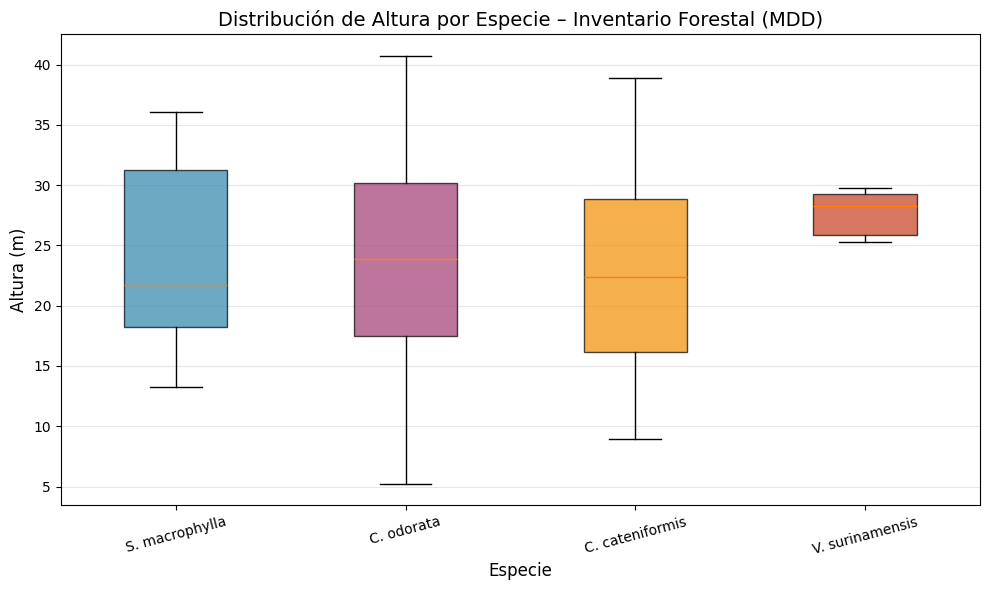

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Preparar datos por especie
especies = ['Swietenia macrophylla', 'Cedrela odorata',
            'Cedrelinga cateniformis', 'Virola surinamensis']
nombres_cortos = ['S. macrophylla', 'C. odorata', 'C. cateniformis', 'V. surinamensis']
datos_por_especie = [datos_arboles[datos_arboles['especie'] == sp]['altura_m']
                     for sp in especies]

# Crear diagrama de caja
bp = ax.boxplot(datos_por_especie, labels=nombres_cortos, patch_artist=True)

# Colorear las cajas
colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Especie', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Distribución de Altura por Especie – Inventario Forestal (MDD)', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 🔬 Ejercicio rápido 1 – Histograma y caja

Usando `calidad_agua`:

1. Crea un histograma del **pH** con media y mediana como líneas verticales
2. Añade una banda sombreada para el rango ECA-MINAM (pH 6.5–8.5)
3. Usa `ax.boxplot()` para comparar el pH por sitio en un segundo subplot

In [ ]:
# Tu código aquí
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: histograma de pH con estadísticas
# ejes[0].hist(...)
# ejes[0].axvline(media_ph, ...)
# ejes[0].axhspan(...)  # <- esto colorea un rango horizontal... usa axvspan para eje x

# Derecha: boxplot de pH por sitio
# sitios = [...]
# datos_por_sitio = [...]
# ejes[1].boxplot(...)

---
## 3. Paneles Múltiples con Subgráficos

Combina múltiples gráficos en una sola figura para comparación o visualización integral.

### 3.1 Cuadrícula básica

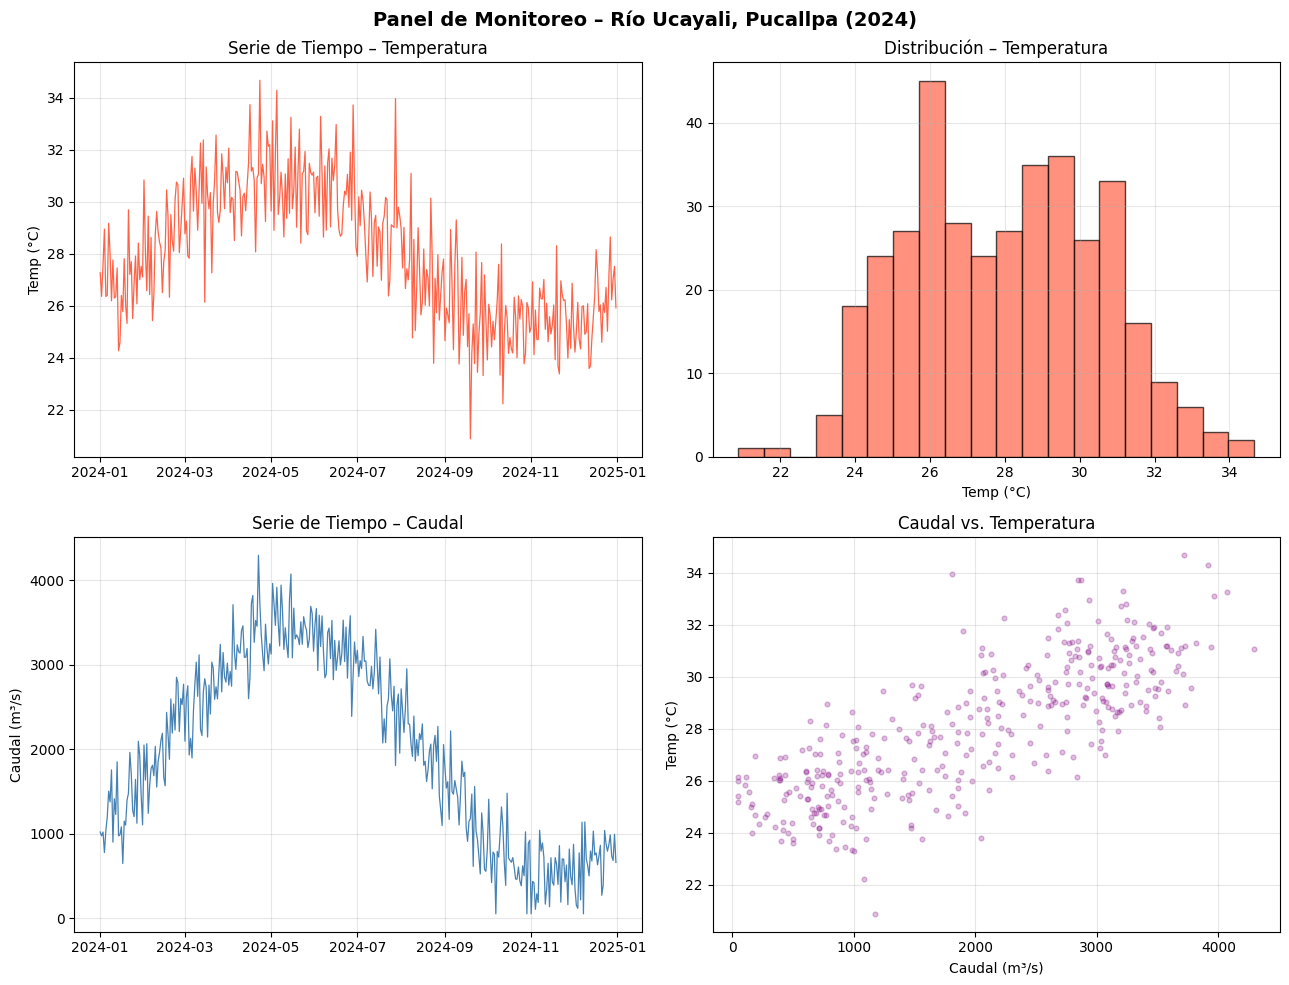

In [4]:
# Cuadrícula 2×2 – Panel de monitoreo del río Ucayali
fig, axis = plt.subplots(2, 2, figsize=(13, 10))

# Superior izquierda: serie de tiempo de temperatura
axis[0, 0].plot(datos_rio['fecha'], datos_rio['temperatura_c'], color='tomato', linewidth=0.9)
axis[0, 0].set_title('Serie de Tiempo – Temperatura')
axis[0, 0].set_ylabel('Temp (°C)')
axis[0, 0].grid(True, alpha=0.3)

# Superior derecha: histograma de temperatura
axis[0, 1].hist(datos_rio['temperatura_c'], bins=20, color='tomato', edgecolor='black', alpha=0.7)
axis[0, 1].set_title('Distribución – Temperatura')
axis[0, 1].set_xlabel('Temp (°C)')
axis[0, 1].grid(True, alpha=0.3)

# Inferior izquierda: serie de tiempo de caudal
axis[1, 0].plot(datos_rio['fecha'], datos_rio['caudal_m3s'], color='steelblue', linewidth=0.9)
axis[1, 0].set_title('Serie de Tiempo – Caudal')
axis[1, 0].set_ylabel('Caudal (m³/s)')
axis[1, 0].grid(True, alpha=0.3)

# Inferior derecha: dispersión caudal vs temperatura
axis[1, 1].scatter(datos_rio['caudal_m3s'], datos_rio['temperatura_c'],
                   alpha=0.25, s=12, color='purple')
axis[1, 1].set_title('Caudal vs. Temperatura')
axis[1, 1].set_xlabel('Caudal (m³/s)')
axis[1, 1].set_ylabel('Temp (°C)')
axis[1, 1].grid(True, alpha=0.3)

fig.suptitle('Panel de Monitoreo – Río Ucayali, Pucallpa (2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Una fila o columna

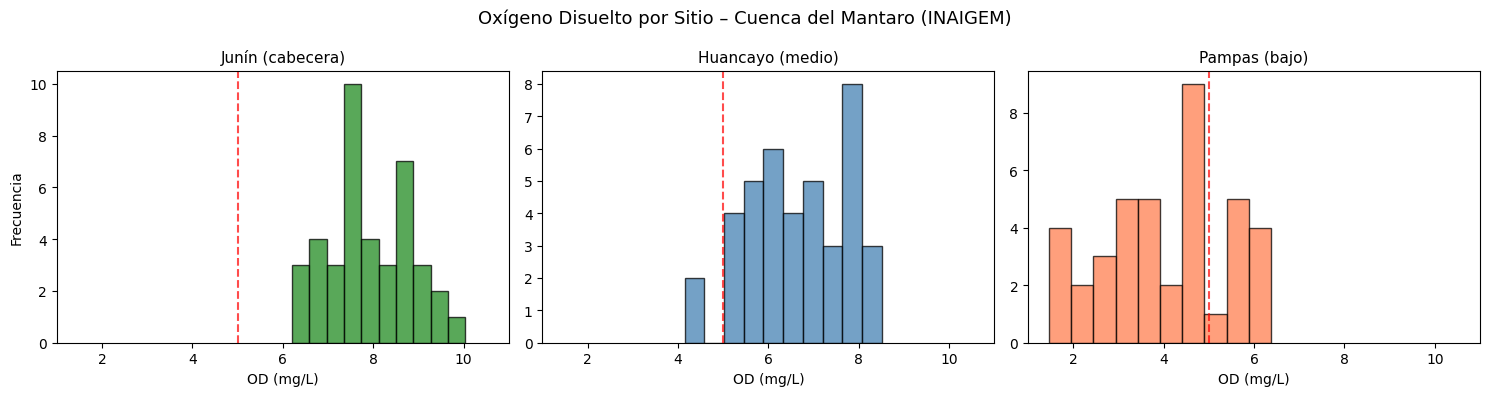

In [6]:
# 1 fila × 3 columnas – OD por sitio de la cuenca del Mantaro
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

sitios  = ['Junín (cabecera)', 'Huancayo (medio)', 'Pampas (bajo)']
colores = ['forestgreen', 'steelblue', 'coral']

for ax, sitio, color in zip(ejes, sitios, colores):
    datos = calidad_agua[calidad_agua['sitio'] == sitio]['oxigeno_disuelto']
    ax.hist(datos, bins=10, color=color, edgecolor='black', alpha=0.75)
    ax.set_title(sitio, fontsize=11)
    ax.set_xlabel('OD (mg/L)')
    ax.set_xlim(1, 11)  # Mismo eje x para comparar
    ax.axvline(5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

ejes[0].set_ylabel('Frecuencia')

plt.suptitle('Oxígeno Disuelto por Sitio – Cuenca del Mantaro (INAIGEM)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Ejes compartidos para facilitar la comparación

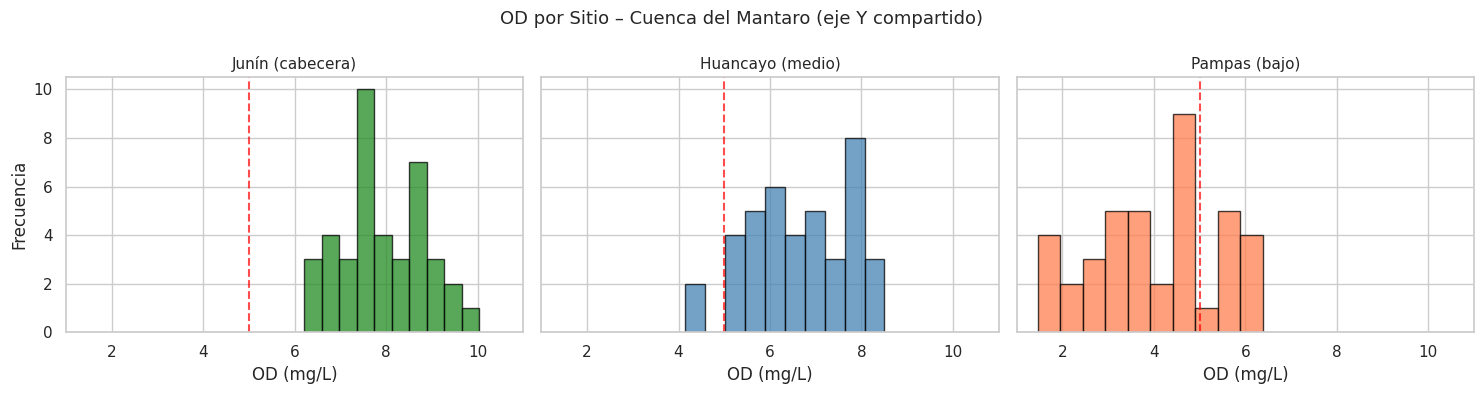

In [13]:
# sharey=True hace que todos los ejes Y sean idénticos
fig, ejes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, sitio, color in zip(ejes, sitios, colores):
    datos = calidad_agua[calidad_agua['sitio'] == sitio]['oxigeno_disuelto']
    ax.hist(datos, bins=10, color=color, edgecolor='black', alpha=0.75)
    ax.set_title(sitio, fontsize=11)
    ax.set_xlabel('OD (mg/L)')
    ax.set_xlim(1, 11)
    ax.axvline(5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

ejes[0].set_ylabel('Frecuencia')  # Solo necesario en el primero

plt.suptitle('OD por Sitio – Cuenca del Mantaro (eje Y compartido)',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Introducción a Seaborn

Seaborn está construido sobre Matplotlib y ofrece:
- Sintaxis más limpia que trabaja directamente con DataFrames
- Mejores estéticas por defecto
- Visualizaciones estadísticas integradas

### 4.1 Seaborn vs. Matplotlib

In [14]:
datos_arboles['name'] = datos_arboles['especie'].apply(
    lambda e: e.split()[0][0]+'. '+e.split()[1][:4]+'.')
datos_arboles

,especie,dap_cm,parcela,altura_m,name
0,Cedrelinga cateniformis,64.793787,MDD_023,33.597157,C. cate.
1,Swietenia macrophylla,26.419972,MDD_023,20.697748,S. macr.
2,Swietenia macrophylla,31.086918,MDD_025,18.960226,S. macr.
3,Cedrela odorata,43.600558,MDD_025,25.839177,C. odor.
4,Cedrelinga cateniformis,64.605125,MDD_024,33.192529,C. cate.
...,...,...,...,...,...
115,Cedrela odorata,17.377259,MDD_025,14.705179,C. odor.
116,Cedrela odorata,31.607076,MDD_024,13.527072,C. odor.
117,Cedrela odorata,68.932021,MDD_023,34.522842,C. odor.
118,Swietenia macrophylla,44.672765,MDD_025,20.185705,S. macr.


NameError: name 'especies' is not defined

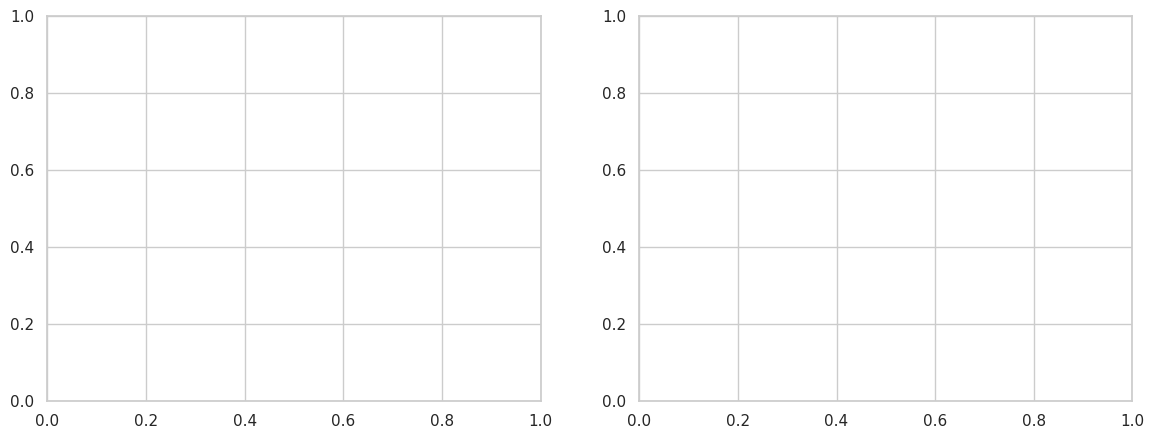

In [15]:
# Establecer estilo de Seaborn
sns.set_theme(style="whitegrid")

# Comparación: diagrama de caja con Matplotlib vs. Seaborn
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Matplotlib (más código)
datos_por_especie = [datos_arboles[datos_arboles['especie'] == sp]['altura_m']
                     for sp in especies]
ejes[0].boxplot(datos_por_especie, labels=nombres_cortos)
ejes[0].set_title('Matplotlib', fontsize=12)
ejes[0].set_ylabel('Altura (m)')
ejes[0].tick_params(axis='x', rotation=15)

# Seaborn (¡una línea!)
# Crear columna con nombre corto para el gráfico
sns.boxplot(data=datos_arboles, x='name', y='altura_m', ax=ejes[1])
ejes[1].set_title('Seaborn', fontsize=12)
ejes[1].set_xlabel('Especie')

plt.tight_layout()
plt.show()

### 4.2 Histogramas con KDE

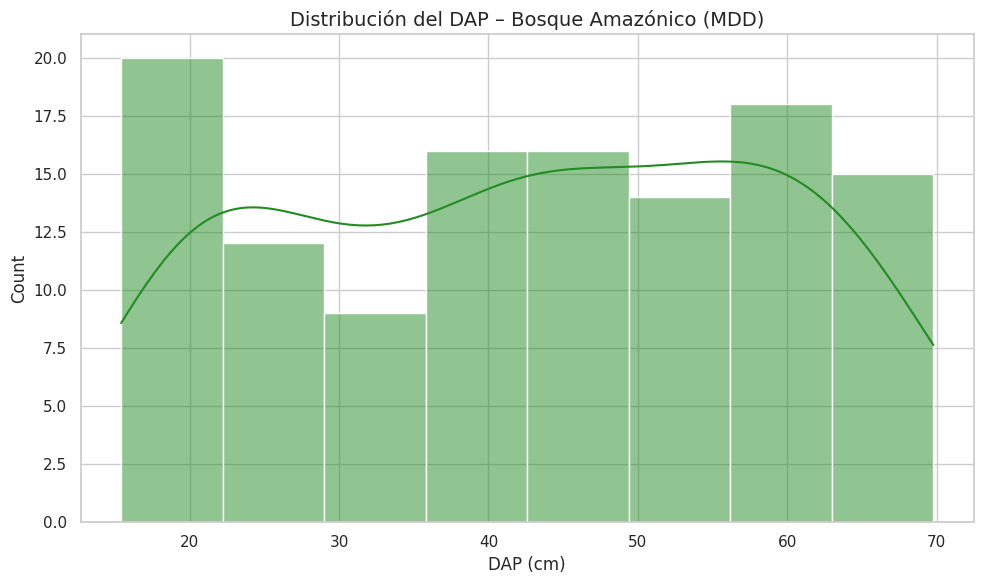

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma con estimación de densidad del núcleo (KDE)
sns.histplot(data=datos_arboles, x='dap_cm', kde=True, color='forestgreen', ax=ax)

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_title('Distribución del DAP – Bosque Amazónico (MDD)', fontsize=14)

plt.tight_layout()
plt.show()

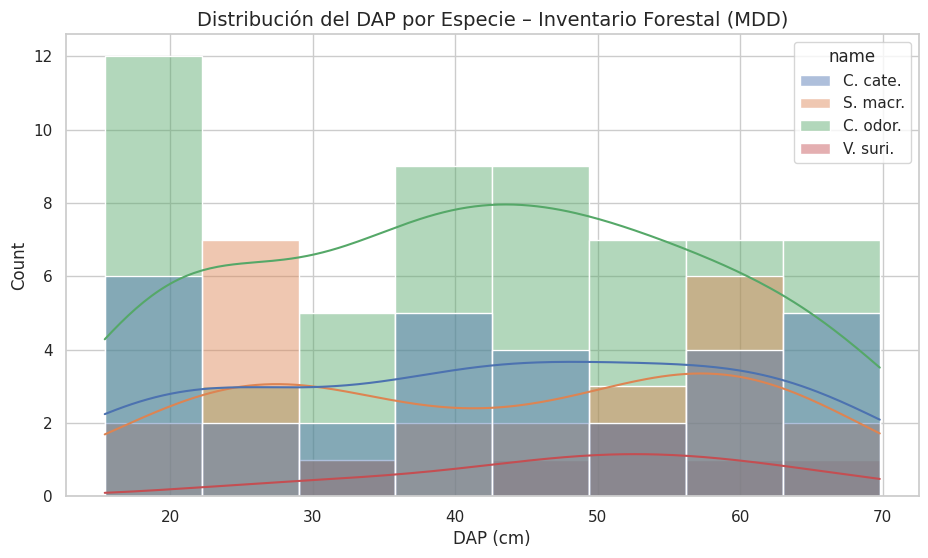

In [ ]:
# Separar por categoría usando 'hue'
fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(data=datos_arboles, x='dap_cm', hue='name',
             kde=True, alpha=0.45, ax=ax)

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_title('Distribución del DAP por Especie – Inventario Forestal (MDD)', fontsize=14)

# plt.tight_layout()
plt.show()

### 4.3 Diagramas de caja y violín

/tmp/ipykernel_2321/1950156603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',
/tmp/ipykernel_2321/1950156603.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',


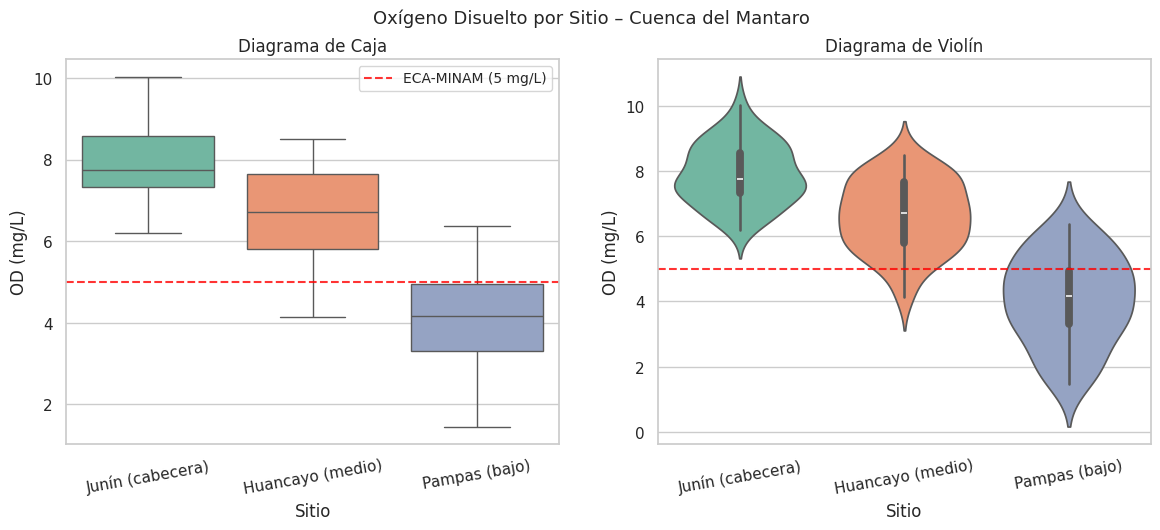

In [17]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Diagrama de caja
sns.boxplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',
            palette='Set2', ax=ejes[0])
ejes[0].axhline(5, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
                label='ECA-MINAM (5 mg/L)')
ejes[0].set_title('Diagrama de Caja', fontsize=12)
ejes[0].set_ylabel('OD (mg/L)')
ejes[0].set_xlabel('Sitio')
ejes[0].legend(fontsize=10)
ejes[0].tick_params(axis='x', rotation=10)

# Diagrama de violín – muestra la forma completa de la distribución
sns.violinplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',
               palette='Set2', ax=ejes[1])
ejes[1].axhline(5, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ejes[1].set_title('Diagrama de Violín', fontsize=12)
ejes[1].set_ylabel('OD (mg/L)')
ejes[1].set_xlabel('Sitio')
ejes[1].tick_params(axis='x', rotation=10)

plt.suptitle('Oxígeno Disuelto por Sitio – Cuenca del Mantaro', fontsize=13)
#plt.tight_layout()
plt.show()

### 4.4 Diagrama de caja con puntos individuales

/tmp/ipykernel_22779/956165815.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=calidad_agua, x='sitio', y='ph',


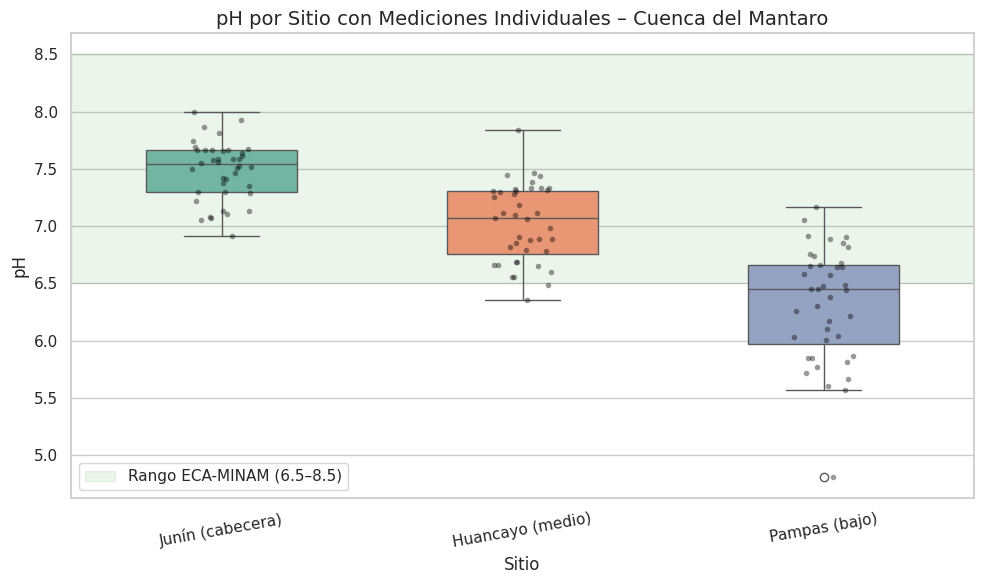

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Combinar boxplot con stripplot para mostrar puntos individuales
sns.boxplot(data=calidad_agua, x='sitio', y='ph',
            palette='Set2', width=0.5, ax=ax)
sns.stripplot(data=calidad_agua, x='sitio', y='ph',
              color='black', alpha=0.4, size=4, ax=ax)

# Rango ECA-MINAM para pH
ax.axhspan(6.5, 8.5, color='green', alpha=0.08, label='Rango ECA-MINAM (6.5–8.5)')
ax.legend(fontsize=11)

ax.set_xlabel('Sitio', fontsize=12)
ax.set_ylabel('pH', fontsize=12)
ax.set_title('pH por Sitio con Mediciones Individuales – Cuenca del Mantaro', fontsize=14)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

### 4.5 Dispersión con regresión

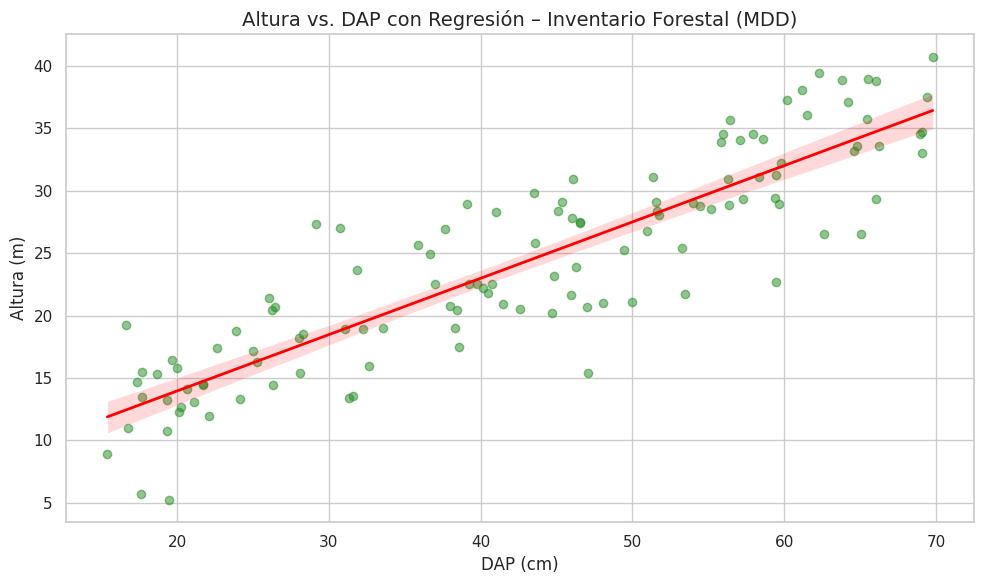

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Dispersión con línea de regresión e intervalo de confianza automáticos
sns.regplot(data=datos_arboles, x='dap_cm', y='altura_m',
            scatter_kws={'alpha': 0.5, 'color': 'forestgreen'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax)

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Altura vs. DAP con Regresión – Inventario Forestal (MDD)', fontsize=14)

plt.tight_layout()
plt.show()

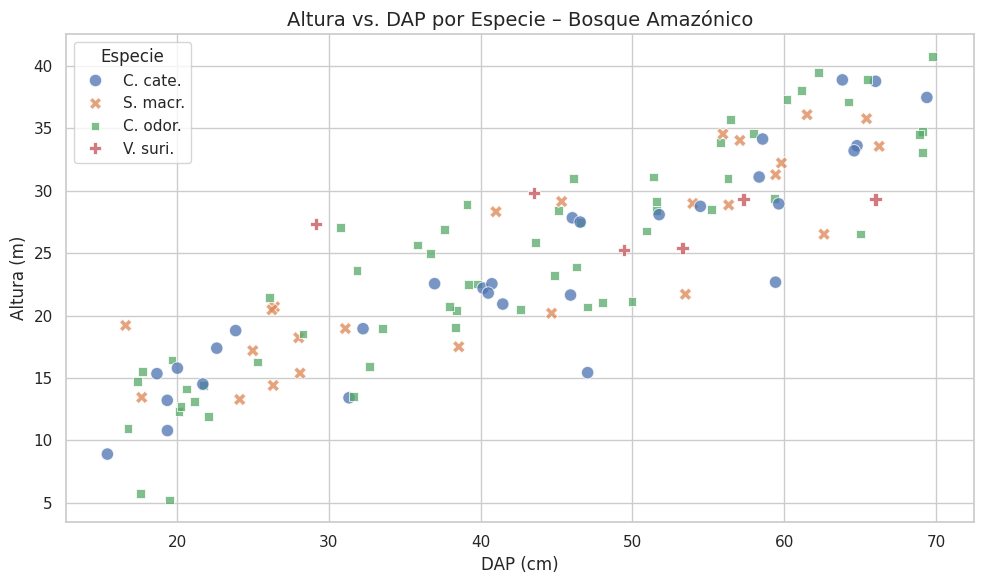

In [ ]:
# Dispersión coloreada por categoría
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=datos_arboles, x='dap_cm', y='altura_m',
                hue='name', style='name',
                s=80, alpha=0.75, ax=ax)

ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Altura vs. DAP por Especie – Bosque Amazónico', fontsize=14)
ax.legend(title='Especie')

plt.tight_layout()
plt.show()

### 4.6 Pair plots para exploración

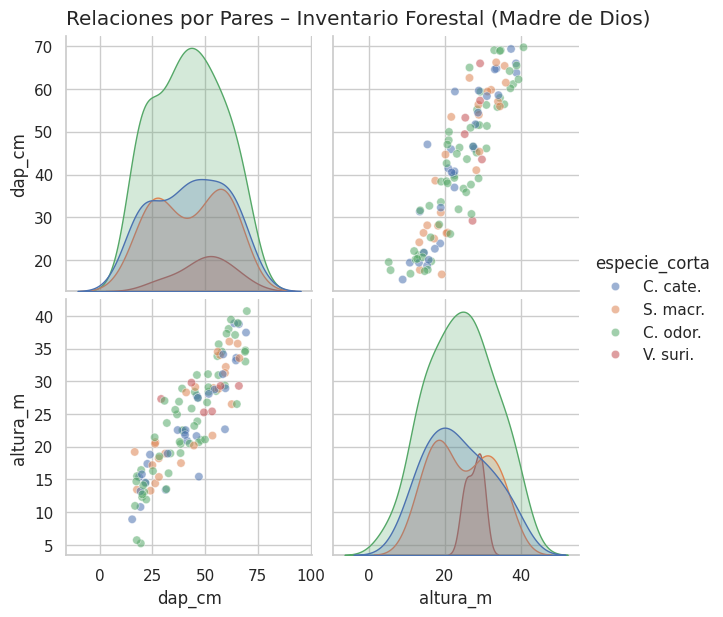

In [ ]:
# Visualizar rápidamente todas las relaciones por pares
sns.pairplot(datos_arboles[['dap_cm', 'altura_m', 'especie']],
             hue='especie', height=3,
             plot_kws={'alpha': 0.55})

plt.suptitle('Relaciones por Pares – Inventario Forestal (Madre de Dios)', y=1.02)
plt.show()

### 🔬 Ejercicio rápido 2 – Seaborn

Usando `datos_rio` con las columnas `temperatura_c`, `caudal_m3s` y `estacion`:

1. Crea un `violinplot` de temperatura por estación (`hue='estacion'`)
2. Crea un `scatterplot` de temperatura vs. caudal, coloreado por estación
3. Añade una línea horizontal en temperatura = 28°C (umbral de estrés térmico para peces amazónicos)

In [ ]:
# Tu código aquí
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: violinplot temperatura por estación
# sns.violinplot(data=datos_rio, x='estacion', y='temperatura_c', ...)

# Derecha: scatterplot temperatura vs caudal por estación
# sns.scatterplot(data=datos_rio, x='caudal_m3s', y='temperatura_c', hue='estacion', ...)
# ejes[1].axhline(28, ...)

---
## 5. Guardar figuras

### 5.1 Guardado básico

/tmp/ipykernel_2321/983559585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos_arboles, x='especie', y='altura_m',


¡Figuras guardadas!


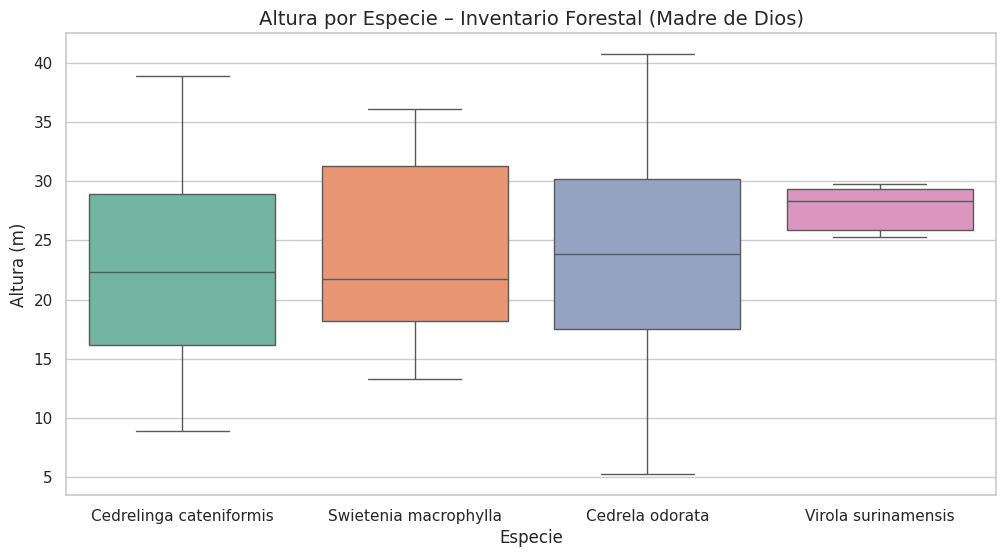

In [19]:
# Crear una figura de calidad de publicación
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=datos_arboles, x='especie', y='altura_m',
            palette='Set2', ax=ax)
ax.set_xlabel('Especie', fontsize=12)
ax.set_ylabel('Altura (m)', fontsize=12)
ax.set_title('Altura por Especie – Inventario Forestal (Madre de Dios)', fontsize=14)

# Guardar como PNG (bueno para presentaciones y web)
fig.savefig('altura_boxplot_mdd.png', dpi=300, bbox_inches='tight')

# Guardar como PDF (bueno para publicaciones, formato vectorial)
fig.savefig('altura_boxplot_mdd.pdf', bbox_inches='tight')

print("¡Figuras guardadas!")
plt.show()

### 5.2 Parámetros clave

In [20]:
print("""
Parámetros clave de fig.savefig():
══════════════════════════════════════════════════════════════

dpi=300              Resolución (300 es el estándar para publicaciones)
bbox_inches='tight'  Elimina el espacio en blanco alrededor de la figura
facecolor='white'    Color de fondo (por defecto transparente en PNG)
transparent=True     Fondo transparente (para PNG)

Formatos comunes:
──────────────────────────────────────────────────────────────
.png    Raster, ideal para web y presentaciones
.pdf    Vectorial, mejor para publicaciones científicas
.svg    Vectorial, ideal para editar en software de diseño
.jpg    Raster, archivos más pequeños pero con compresión con pérdida

══════════════════════════════════════════════════════════════
"""
)


Parámetros clave de fig.savefig():
══════════════════════════════════════════════════════════════

dpi=300              Resolución (300 es el estándar para publicaciones)
bbox_inches='tight'  Elimina el espacio en blanco alrededor de la figura
facecolor='white'    Color de fondo (por defecto transparente en PNG)
transparent=True     Fondo transparente (para PNG)

Formatos comunes:
──────────────────────────────────────────────────────────────
.png    Raster, ideal para web y presentaciones
.pdf    Vectorial, mejor para publicaciones científicas
.svg    Vectorial, ideal para editar en software de diseño
.jpg    Raster, archivos más pequeños pero con compresión con pérdida

══════════════════════════════════════════════════════════════



In [ ]:
# Descargar archivos en Colab
# from google.colab import files
# files.download('altura_boxplot_mdd.png')

---
## 6. Ejercicio integrador

Crea una figura con **2 filas × 2 columnas** que muestre un análisis completo del río Ucayali y la cuenca del Mantaro:

1. **(Superior izquierda)** Violín de `temperatura_c` por `estacion` del río Ucayali
2. **(Superior derecha)** Dispersión `caudal_m3s` vs. `temperatura_c`, coloreada por `estacion`
3. **(Inferior izquierda)** Boxplot + stripplot de `oxigeno_disuelto` por `sitio` (cuenca Mantaro)
4. **(Inferior derecha)** Histplot de `ph` por `sitio` (cuenca Mantaro) con KDE

Guarda la figura como PNG con dpi=300.

/tmp/ipykernel_2321/2792926552.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=datos_rio, x='estacion', y='temperatura_c',
/tmp/ipykernel_2321/2792926552.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',


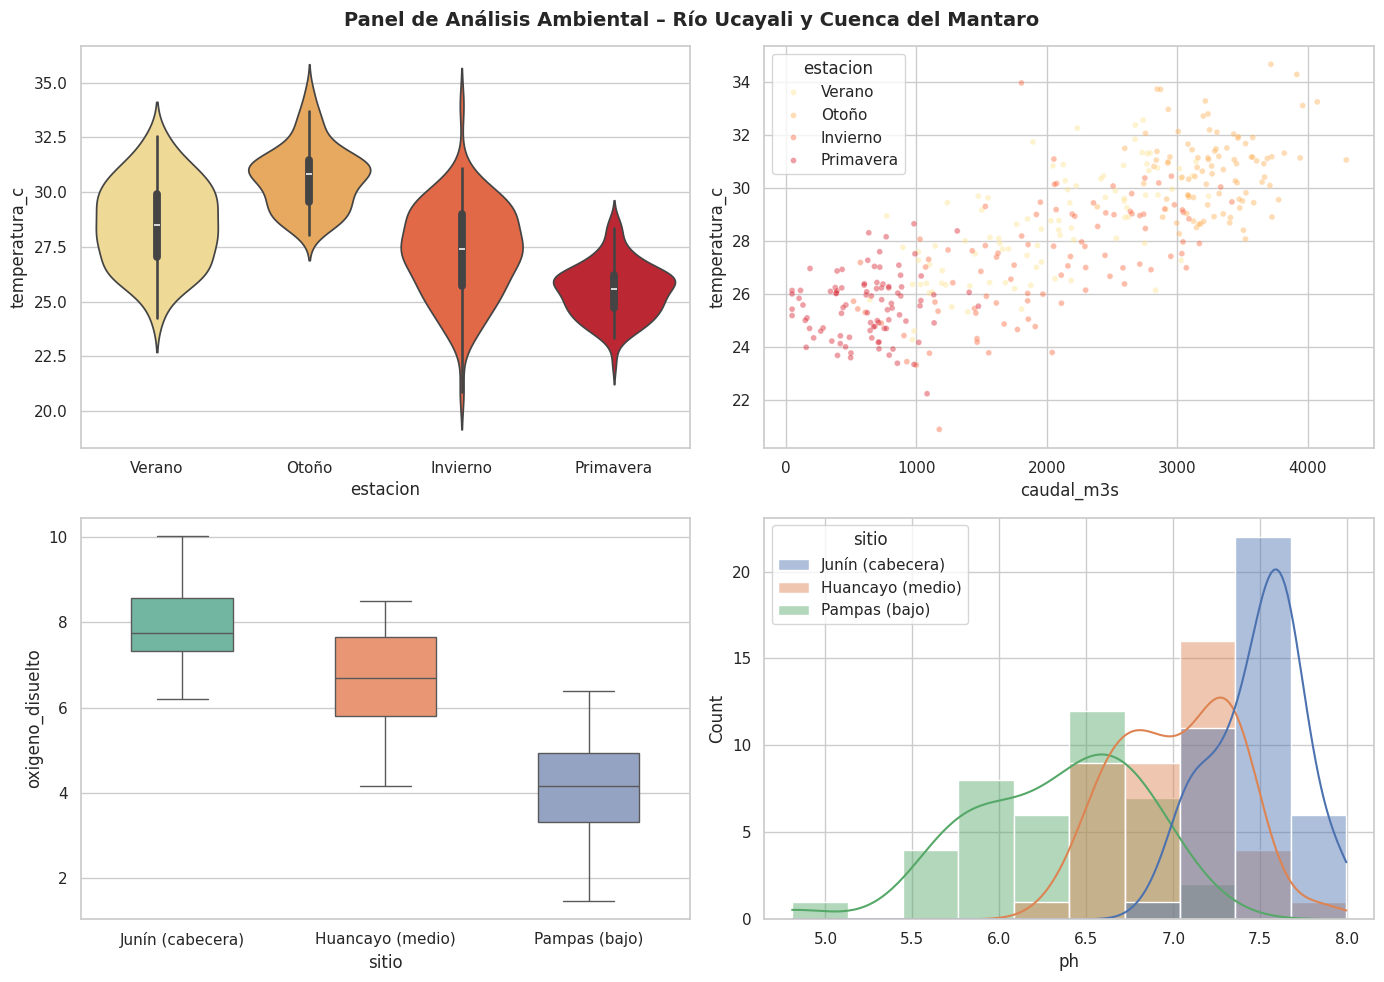

In [24]:
# Tu código aquí
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# ── (0,0) Violín temperatura por estación ──
sns.violinplot(data=datos_rio, x='estacion', y='temperatura_c',
               palette='YlOrRd', ax=ejes[0,0])
# ── (0,1) Dispersión caudal vs temperatura ──
sns.scatterplot(data=datos_rio, x='caudal_m3s', y='temperatura_c',
                hue='estacion', palette='YlOrRd', alpha=0.4, s=18, ax=ejes[0,1])
# ── (1,0) Boxplot + stripplot OD por sitio ──
sns.boxplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',
            palette='Set2', width=0.5, ax=ejes[1,0])
# ── (1,1) Histplot pH por sitio ──
sns.histplot(data=calidad_agua, x='ph', hue='sitio',
             kde=True, alpha=0.45, ax=ejes[1,1])
fig.suptitle('Panel de Análisis Ambiental – Río Ucayali y Cuenca del Mantaro',
             fontsize=14, fontweight='bold')
plt.tight_layout()

# fig.savefig('panel_ambiental_peru.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Resumen

### Guía de selección de tipo de gráfico

| Tipo de dato | Tipo de gráfico | Función |
|--------------|-----------------|---------|
| Distribución (1 variable) | Histograma | `ax.hist()`, `sns.histplot()` |
| Comparar distribuciones | Caja, Violín | `sns.boxplot()`, `sns.violinplot()` |
| Relación (2 variables) | Dispersión | `ax.scatter()`, `sns.scatterplot()` |
| Tendencia en el tiempo | Línea | `ax.plot()` |
| Comparar categorías | Barras | `ax.bar()` |

### Ventajas de Seaborn
- Trabaja directamente con DataFrames
- Parámetro `hue` para agrupaciones sencillas
- Funciones estadísticas integradas (KDE, regresión, IC)
- Mejores estéticas por defecto

### Buenas prácticas al guardar
- Usar `dpi=300` para publicaciones científicas
- Usar `bbox_inches='tight'` para eliminar espacio en blanco
- PDF para publicaciones (formato vectorial)
- PNG para presentaciones y web

---
## Soluciones

In [ ]:
# Solución Ejercicio rápido 1 – pH: histograma y boxplot
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: histograma de pH con estadísticas
ph_todos = calidad_agua['ph']
ejes[0].hist(ph_todos, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ejes[0].axvline(ph_todos.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Media: {ph_todos.mean():.2f}')
ejes[0].axvline(ph_todos.median(), color='orange', linestyle=':',  linewidth=2,
                label=f'Mediana: {ph_todos.median():.2f}')
ejes[0].axvspan(6.5, 8.5, color='green', alpha=0.12, label='Rango ECA-MINAM')
ejes[0].set_xlabel('pH', fontsize=12)
ejes[0].set_ylabel('Frecuencia', fontsize=12)
ejes[0].set_title('Distribución del pH – Cuenca del Mantaro')
ejes[0].legend()

# Derecha: boxplot de pH por sitio
sitios_lista = ['Junín (cabecera)', 'Huancayo (medio)', 'Pampas (bajo)']
datos_ph_por_sitio = [calidad_agua[calidad_agua['sitio'] == s]['ph']
                      for s in sitios_lista]
bp = ejes[1].boxplot(datos_ph_por_sitio, labels=['Junín', 'Huancayo', 'Pampas'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['forestgreen', 'steelblue', 'coral']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ejes[1].axhline(6.5, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
                label='ECA mín. (6.5)')
ejes[1].axhline(8.5, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ejes[1].set_ylabel('pH', fontsize=12)
ejes[1].set_title('pH por Sitio – Cuenca del Mantaro')
ejes[1].legend()
ejes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Solución Ejercicio rápido 2 – Seaborn: temperatura y caudal por estación
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Izquierda: violinplot temperatura por estación
sns.violinplot(data=datos_rio, x='estacion', y='temperatura_c',
               palette='coolwarm', ax=ejes[0])
ejes[0].axhline(28, color='red', linestyle='--', linewidth=2,
                label='Umbral estrés térmico (28°C)')
ejes[0].set_xlabel('Estación', fontsize=12)
ejes[0].set_ylabel('Temperatura (°C)', fontsize=12)
ejes[0].set_title('Temperatura por Estación – Río Ucayali', fontsize=13)
ejes[0].legend(fontsize=10)

# Derecha: scatter temperatura vs caudal por estación
sns.scatterplot(data=datos_rio, x='caudal_m3s', y='temperatura_c',
                hue='estacion', palette='coolwarm', alpha=0.5, s=20, ax=ejes[1])
ejes[1].axhline(28, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ejes[1].set_xlabel('Caudal (m³/s)', fontsize=12)
ejes[1].set_ylabel('Temperatura (°C)', fontsize=12)
ejes[1].set_title('Temperatura vs. Caudal por Estación', fontsize=13)
ejes[1].legend(title='Estación')

plt.tight_layout()
fig.savefig('analisis_rio_ucayali.png', dpi=300, bbox_inches='tight')
print("Figura guardada como 'analisis_rio_ucayali.png'")
plt.show()

In [ ]:
# Solución Ejercicio integrador – Panel completo
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# ── (0,0) Violín temperatura por estación ──
sns.violinplot(data=datos_rio, x='estacion', y='temperatura_c',
               palette='YlOrRd', ax=ejes[0,0])
ejes[0,0].set_xlabel('Estación'); ejes[0,0].set_ylabel('Temperatura (°C)')
ejes[0,0].set_title('Temperatura por Estación – Río Ucayali')

# ── (0,1) Dispersión caudal vs temperatura ──
sns.scatterplot(data=datos_rio, x='caudal_m3s', y='temperatura_c',
                hue='estacion', palette='YlOrRd', alpha=0.4, s=18, ax=ejes[0,1])
ejes[0,1].axhline(28, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ejes[0,1].set_xlabel('Caudal (m³/s)'); ejes[0,1].set_ylabel('Temperatura (°C)')
ejes[0,1].set_title('Caudal vs. Temperatura – Río Ucayali')

# ── (1,0) Boxplot + stripplot OD ──
sns.boxplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',
            palette='Set2', width=0.5, ax=ejes[1,0])
sns.stripplot(data=calidad_agua, x='sitio', y='oxigeno_disuelto',
              color='black', alpha=0.4, size=4, ax=ejes[1,0])
ejes[1,0].axhline(5, color='red', linestyle='--', linewidth=1.5,
                   label='ECA-MINAM (5 mg/L)')
ejes[1,0].set_xlabel('Sitio'); ejes[1,0].set_ylabel('OD (mg/L)')
ejes[1,0].set_title('OD por Sitio – Cuenca del Mantaro')
ejes[1,0].legend(fontsize=9)
ejes[1,0].tick_params(axis='x', rotation=10)

# ── (1,1) Histplot pH por sitio ──
sns.histplot(data=calidad_agua, x='ph', hue='sitio',
             kde=True, alpha=0.45, ax=ejes[1,1])
ejes[1,1].axvspan(6.5, 8.5, color='green', alpha=0.08, label='ECA-MINAM pH')
ejes[1,1].set_xlabel('pH'); ejes[1,1].set_ylabel('Frecuencia')
ejes[1,1].set_title('pH por Sitio – Cuenca del Mantaro')
ejes[1,1].legend(fontsize=9)

fig.suptitle('Panel de Análisis Ambiental – Río Ucayali y Cuenca del Mantaro',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('panel_ambiental_peru.png', dpi=300, bbox_inches='tight')
print("Figura guardada como 'panel_ambiental_peru.png'")
plt.show()